# Image → Desmos art (region outlines + stroke detail + conics)


## 1 · Setup (silent)

In [ ]:
%%capture
!pip install opencv-python-headless numpy pillow scikit-image matplotlib scipy
print('deps ready')

## 2 · The converter

In [ ]:
%%writefile desmos_mega.py

import os
import json
import time
import argparse
import warnings
from collections import Counter

import cv2
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.spatial import cKDTree

warnings.filterwarnings("ignore")
USE_CONICS = True


# ------------------------------------------------------------------ load
def load_image(image_path, max_size=1600):
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(image_path)
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    if img.shape[2] == 4:
        alpha = img[:, :, 3:4] / 255.0
        img = (img[:, :, :3].astype(float) * alpha
               + 255 * (1 - alpha)).astype(np.uint8)
    h, w = img.shape[:2]
    s = max_size / max(h, w)
    interp = cv2.INTER_CUBIC if s > 1 else cv2.INTER_AREA
    return cv2.resize(img, (int(round(w * s)), int(round(h * s))),
                      interpolation=interp)


# ------------------------------------------------------ 1+2: clean edges
def detect_edges(img, sens=1.5, sigma=1.2, nlm=5, border=4):
    """Denoised, border-safe, hysteresis Canny on luminance -> bool mask.
    sens < 1 keeps more faint detail, sens > 1 is stricter/cleaner."""
    from skimage.feature import canny
    P = 24                                    # reflect pad: no border artefacts
    pad = cv2.copyMakeBorder(img, P, P, P, P, cv2.BORDER_REFLECT)
    if nlm > 0:
        pad = cv2.fastNlMeansDenoisingColored(pad, None, nlm, nlm, 5, 15)
    L = cv2.cvtColor(pad, cv2.COLOR_BGR2LAB)[..., 0].astype(np.float32) \
        * (100.0 / 255.0)
    e = canny(L, sigma=sigma, low_threshold=0.7 * sens,
              high_threshold=2.0 * sens)
    e = e[P:-P, P:-P]
    if border > 0:                            # kill any residual frame
        e[:border] = e[-border:] = False
        e[:, :border] = e[:, -border:] = False
    return e


# ---------------------------------------------- 3: merge + 1px skeleton
def centerline(edges, merge=0, min_comp=18, seal=False):
    """Edges -> clean 1 px skeleton, speck islands removed.

    seal  : OPTIONAL 3x3 closing for 1-px gaps; off by default (it fuses
            lines that are 2 px apart in dense areas).
    merge : OPTIONAL. >0 fills enclosed gaps up to this many px wide so the
            double edge of a thin stroke becomes one centerline.  Off by
            default: on dense art (eyes, hair) it fuses neighbouring lines
            into blobs whose skeleton is a 'cell wall' mess."""
    from scipy import ndimage as ndi
    from skimage.morphology import skeletonize, remove_small_objects
    m = edges.astype(np.uint8)
    if seal:
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    if merge > 0:
        bg = m == 0
        lab, n = ndi.label(bg)                             # 4-connected holes
        if n:
            dt = ndi.distance_transform_edt(bg)
            widest = ndi.maximum(dt, lab, index=np.arange(1, n + 1))
            outer = np.unique(np.concatenate(
                [lab[0], lab[-1], lab[:, 0], lab[:, -1]]))
            ids = np.arange(1, n + 1)
            fill = ids[(widest <= merge / 2.0) & ~np.isin(ids, outer)]
            m[np.isin(lab, fill)] = 1
    sk = skeletonize(m > 0)
    if min_comp > 0:
        sk = remove_small_objects(sk, min_size=min_comp, connectivity=2)
    return sk


# ----------------------------------------- 4: skeleton graph -> paths
_N8 = [(-1, -1), (-1, 0), (-1, 1), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1)]


def _crossing(sk):
    """crossing number per pixel (>=3 => junction), and neighbour count."""
    p = np.pad(sk.astype(np.uint8), 1)
    H, W = sk.shape
    nb = [p[1 + dy:1 + dy + H, 1 + dx:1 + dx + W] for dy, dx in _N8]
    cn = np.zeros((H, W), np.uint8)
    for i in range(8):
        cn += ((nb[i] == 0) & (nb[(i + 1) % 8] == 1)).astype(np.uint8)
    cnt = sum(n.astype(np.uint8) for n in nb)
    return cn, cnt


def _walk(pixels):
    """Order the pixels of one thin component into one or more paths.
    Branches that the crossing-number test misses are walked as extra paths,
    so no skeleton pixel is ever silently dropped."""
    S = set(pixels)
    seen = set()

    def nbrs(q, pool):
        y, x = q
        return [(y + dy, x + dx) for dy, dx in _N8 if (y + dy, x + dx) in pool]

    out = []
    while len(seen) < len(S):
        left = [q for q in pixels if q not in seen]
        pool = set(left)
        start = next((q for q in left if len(nbrs(q, pool)) <= 1), left[0])
        path, cur = [start], start
        seen.add(start)
        while True:
            cand = [n for n in nbrs(cur, S) if n not in seen]
            if not cand:
                break
            cand.sort(key=lambda n: abs(n[0] - cur[0]) + abs(n[1] - cur[1]))
            cur = cand[0]
            path.append(cur)
            seen.add(cur)
        out.append(path)
    return out


def trace_paths(sk, spur=8, rounds=2):
    """Skeleton -> list of ordered paths (arrays of (x, y)); prunes spurs."""
    from scipy import ndimage as ndi
    sk = sk.copy()
    stats = {"spurs_pruned": 0}
    for r in range(rounds + 1):
        cn, cnt = _crossing(sk)
        junc = sk & (cn >= 3)
        seg = sk & ~junc
        lab, n = ndi.label(seg, structure=np.ones((3, 3)))
        ys, xs = np.nonzero(seg)
        order = np.argsort(lab[ys, xs], kind="stable")
        ys, xs, ls = ys[order], xs[order], lab[ys, xs][order]
        cuts = np.flatnonzero(np.diff(ls)) + 1
        jset = set(zip(*np.nonzero(junc)))
        paths, touching = [], []
        for gy, gx in zip(np.split(ys, cuts), np.split(xs, cuts)):
            if len(gy) == 0:
                continue
            for p in _walk(list(zip(gy.tolist(), gx.tolist()))):
                ends_j = []
                for end in (p[0], p[-1]):
                    j = [(end[0] + dy, end[1] + dx) for dy, dx in _N8
                         if (end[0] + dy, end[1] + dx) in jset]
                    ends_j.append(j)
                paths.append((p, ends_j))
        if r == rounds:
            break
        removed = 0                      # prune short branches ending free
        for p, ej in paths:
            free0, free1 = not ej[0], not ej[1]
            if len(p) < spur and (free0 != free1):
                for q in p:
                    sk[q] = False
                removed += 1
        stats["spurs_pruned"] += removed
        if removed == 0:
            break
    out = []
    for p, ej in paths:
        pts = [q for q in p]
        if ej[0]:
            pts = [ej[0][0]] + pts       # reconnect through the junction
        if ej[1]:
            pts = pts + [ej[1][0]]
        a = np.array(pts, float)[:, ::-1]            # (y,x) -> (x,y)
        out.append(a)
    return out, stats


# ------------------------------------------------------- 5: curve fitting
def _is_closed(pts, tol=2.5):
    return len(pts) >= 12 and float(np.hypot(*(pts[0] - pts[-1]))) <= tol


def _path_len(pts):
    return float(np.hypot(*np.diff(pts, axis=0).T).sum())


def smooth_path(pts, sigma, closed):
    if sigma <= 0 or len(pts) < 5:
        return pts
    if closed:
        core = pts[:-1]
        x = gaussian_filter1d(core[:, 0], sigma, mode="wrap")
        y = gaussian_filter1d(core[:, 1], sigma, mode="wrap")
        c = np.stack([x, y], 1)
        return np.vstack([c, c[:1]])
    x = gaussian_filter1d(pts[:, 0], sigma, mode="nearest")
    y = gaussian_filter1d(pts[:, 1], sigma, mode="nearest")
    out = np.stack([x, y], 1)
    out[0], out[-1] = pts[0], pts[-1]     # keep junction attachments exact
    return out


def _try_conic(pts, err):
    """Ellipse only (parabola/hyperbola fits were the v6 noise source)."""
    if not USE_CONICS or len(pts) < 16:
        return None
    cf = _fit_conic_coeffs(pts)
    if cf is None:
        return None
    if cf[0] * cf[2] - cf[1] ** 2 / 4.0 <= 0.05:
        return None
    g = _conic_geom(cf)
    if g is None or g["kind"] != "ellipse":
        return None
    span = float(np.hypot(*(pts.max(0) - pts.min(0))))
    if max(g["a"], g["b"]) > 1.5 * max(span, 1.0):
        return None
    if float(_conic_dists(pts, cf).max()) > err:
        return None
    if _angle_span(pts, g) <= 2.6:
        return None
    g["bbox"] = None
    return g


def _fit_seg(pts, t0, t1, err):
    return _fit_cubic(pts, t0, t1, err)


def fit_path(pts, fit_err, sigma):
    """One ordered pixel path -> list of primitives."""
    closed = _is_closed(pts)
    pts = smooth_path(pts, sigma, closed)
    if len(pts) < 2:
        return []
    chord = pts[-1] - pts[0]
    L = float(np.hypot(*chord))
    if not closed and L > 1e-6:                       # straight? one line
        n = np.array([-chord[1], chord[0]]) / L
        dev = np.abs((pts - pts[0]) @ n).max()
        if dev <= 0.6 * fit_err:
            return [("line", pts[0].copy(), pts[-1].copy())]
    if closed:
        g = _try_conic(pts[:-1], min(fit_err, 1.0))
        if g is not None:
            return [("conic", g)]
        k = len(pts) // 2
        a, b = pts[:k + 1], np.vstack([pts[k:-1], pts[:1]])
        ta = _unit(pts[1] - pts[-2])
        tm = _unit(pts[k - 1] - pts[min(k + 1, len(pts) - 1)])
        return (_fit_seg(a, ta, tm, fit_err)
                + _fit_seg(b, -tm, -ta, fit_err))
    t0 = _unit(pts[min(3, len(pts) - 1)] - pts[0])
    t1 = _unit(pts[max(-4, -len(pts))] - pts[-1])
    return _fit_seg(pts, t0, t1, fit_err)


def paths_to_curves(paths, fit_err=1.2, sigma=1.6, min_len=10):
    """Return list of (length, primitives) per kept path."""
    out = []
    for p in paths:
        ln = _path_len(p)
        if ln < min_len:
            continue
        prims = fit_path(p, fit_err, sigma)
        if prims:
            out.append((ln, prims))
    return out


# ====================== conic section fitting (ellipse) ======================
def _fit_conic_coeffs(pts):
    """General conic via SVD: A x^2 + B xy + C y^2 + D x + E y + F, ||quad||=1."""
    x, y = pts[:, 0], pts[:, 1]
    D = np.column_stack([x * x, x * y, y * y, x, y, np.ones(len(pts))])
    try:
        _, _, Vt = np.linalg.svd(D, full_matrices=False)
    except np.linalg.LinAlgError:
        return None
    cf = Vt[-1]
    n = float(np.linalg.norm(cf[:3]))
    return cf / n if n > 1e-9 else None


def _conic_geom(cf):
    """Classify conic + geometry: kind, center (h,k), axes a>=b, rotation th."""
    A, B, C, D, E, F = cf
    Q = np.array([[A, B / 2], [B / 2, C]])
    Lv = np.array([D, E])
    detQ = A * C - B * B / 4.0
    if abs(detQ) < 1e-9:
        return None
    try:
        center = -0.5 * np.linalg.solve(Q, Lv)
    except np.linalg.LinAlgError:
        return None
    F0 = F + Lv @ center + center @ Q @ center
    if abs(F0) < 1e-12:
        return None
    w, V = np.linalg.eigh(Q)          # ascending eigenvalues
    d1, d0 = -F0 / w[1], -F0 / w[0]
    if detQ > 0:                       # ellipse: both denominators must be > 0
        if d1 <= 0 or d0 <= 0:
            return None                # imaginary ellipse
        a, b = np.sqrt(d1), np.sqrt(d0)
        th = np.arctan2(V[1, 1], V[0, 1])
        kind = "ellipse"
    else:                              # hyperbola: exactly one denominator > 0
        if d1 > 0:
            a, b = np.sqrt(d1), np.sqrt(-d0)
            th = np.arctan2(V[1, 1], V[0, 1])
        else:
            a, b = np.sqrt(d0), np.sqrt(-d1)
            th = np.arctan2(V[1, 0], V[0, 0])
        kind = "hyperbola"
    if not (np.isfinite(a) and np.isfinite(b)) or a <= 0 or b <= 0:
        return None
    return {"kind": kind, "h": float(center[0]), "k": float(center[1]),
            "a": a, "b": b, "th": float(th)}


def _conic_dists(pts, cf):
    A, B, C, D, E, F = cf
    x, y = pts[:, 0], pts[:, 1]
    f = A * x * x + B * x * y + C * y * y + D * x + E * y + F
    gx = 2 * A * x + B * y + D
    gy = B * x + 2 * C * y + E
    return np.abs(f) / np.maximum(np.hypot(gx, gy), 1e-9)


def _arc_bbox(pts, inset=0.25):
    lo = pts.min(0) + inset
    hi = pts.max(0) - inset
    return (float(lo[0]), float(hi[0]), float(lo[1]), float(hi[1]))


def _angle_span(pts, g):
    """Angular coverage of pts around the conic center, in the conic frame."""
    X = pts - np.array([g["h"], g["k"]])
    co, si = np.cos(g["th"]), np.sin(g["th"])
    u = X @ np.array([co, si]) / max(g["a"], 1e-9)
    v = X @ np.array([-si, co]) / max(g["b"], 1e-9)
    ang = np.sort(np.arctan2(v, u))
    gaps = np.diff(np.concatenate([ang, [ang[0] + 2 * np.pi]]))
    return 2 * np.pi - float(gaps.max())


def _finish_conic(pts, g):
    if g["kind"] == "ellipse" and _angle_span(pts, g) > 2.6:
        g["bbox"] = None               # nearly-full ellipse: show it whole
    else:
        g["bbox"] = _arc_bbox(pts)
    return g


# ====================== cubic Bezier curve fitting ======================
def _unit(v):
    n = float(np.hypot(v[0], v[1]))
    return v / n if n > 1e-12 else np.array([1.0, 0.0])


def _chord_u(pts):
    d = np.hypot(np.diff(pts[:, 0]), np.diff(pts[:, 1]))
    u = np.concatenate([[0.0], np.cumsum(d)])
    return u / max(u[-1], 1e-12)


def _bez_eval(P0, P1, P2, P3, u):
    w = 1.0 - u
    return ((w**3)[:, None] * P0 + (3 * w * w * u)[:, None] * P1
            + (3 * w * u * u)[:, None] * P2 + (u**3)[:, None] * P3)


def _bez_d1(P0, P1, P2, P3, u):
    w = 1.0 - u
    return ((3 * w * w)[:, None] * (P1 - P0) + (6 * w * u)[:, None] * (P2 - P1)
            + (3 * u * u)[:, None] * (P3 - P2))


def _generate_bezier(pts, u, t0, t1):
    P0, P3 = pts[0], pts[-1]
    w = 1.0 - u
    a1 = (3 * w * w * u)[:, None] * t0
    a2 = (3 * w * u * u)[:, None] * t1
    c0 = (w * w * (1 + 2 * u))[:, None]       # full coeff of P0 in B(u)
    c3 = (u * u * (3 - 2 * u))[:, None]       # full coeff of P3 in B(u)
    r = pts - c0 * P0 - c3 * P3
    C00, C01 = float((a1 * a1).sum()), float((a1 * a2).sum())
    C11 = float((a2 * a2).sum())
    X0, X1 = float((a1 * r).sum()), float((a2 * r).sum())
    det = C00 * C11 - C01 * C01
    L = float(np.hypot(*(P3 - P0)))
    eps = 1e-6 * max(L, 1e-9)
    fallback = max(L / 3.0, eps)
    if abs(det) < 1e-12 * max(C00 * C11, 1e-18):
        al = ar = fallback
    else:
        al = (X0 * C11 - X1 * C01) / det
        ar = (C00 * X1 - C01 * X0) / det
        bad = (not np.isfinite(al)) or (not np.isfinite(ar)) \
            or al < eps or ar < eps or al > 4 * L or ar > 4 * L
        if bad:
            al = ar = fallback
    return P0, P0 + al * t0, P3 + ar * t1, P3


def _reparam(pts, bez, u):
    P0, P1, P2, P3 = bez
    for _ in range(4):
        q = _bez_eval(P0, P1, P2, P3, u) - pts
        q1 = _bez_d1(P0, P1, P2, P3, u)
        step = (q * q1).sum(1) / np.maximum((q1 * q1).sum(1), 1e-12)
        u = np.clip(u - step, 1e-4, 1.0 - 1e-4)
    return u


def _max_error(pts, bez, u):
    q = _bez_eval(*bez, u) - pts
    dist = np.hypot(q[:, 0], q[:, 1])
    i = int(np.argmax(dist))
    return float(dist[i]), i


def _center_tangent(pts, i):
    return _unit(pts[i - 1] - pts[min(i + 1, len(pts) - 1)])


def _fit_cubic(pts, t0, t1, err):
    n = len(pts)
    if n == 2:
        return [("line", pts[0], pts[1])]
    u = _chord_u(pts)
    bez = _generate_bezier(pts, u, t0, t1)
    e, i = _max_error(pts, bez, u)
    if e > err:
        u = _reparam(pts, bez, u)
        bez = _generate_bezier(pts, u, t0, t1)
        e, i = _max_error(pts, bez, u)
    if e <= err:
        return [bez]
    if i < 1 or i > n - 2:
        i = n // 2
    ct = _center_tangent(pts, i)
    return (_fit_seg(pts[:i + 1], t0, ct, err)
            + _fit_seg(pts[i:], -ct, t1, err))



# ------------------------------------------------------- coords + latex
def _to_math(p, h, w, scale):
    return ((p[0] - w / 2.0) * scale, (h / 2.0 - p[1]) * scale)


def curves_to_math(curves, h, w, scale=1.0):
    out = []
    for c in curves:
        if isinstance(c[0], str):
            if c[0] == "line":
                out.append(("line", _to_math(c[1], h, w, scale),
                            _to_math(c[2], h, w, scale)))
            else:  # conic
                g = dict(c[1])
                g["h"], g["k"] = _to_math((g["h"], g["k"]), h, w, scale)
                g["a"] *= scale
                if np.isfinite(g.get("b", float("nan"))):
                    g["b"] *= scale
                bb = g.get("bbox")
                if bb is not None:
                    g["bbox"] = ((bb[0] - w / 2.0) * scale,
                                 (bb[1] - w / 2.0) * scale,
                                 (h / 2.0 - bb[3]) * scale,
                                 (h / 2.0 - bb[2]) * scale)
                out.append(("conic", g))
        else:
            out.append(tuple(_to_math(p, h, w, scale) for p in c))
    return out


def _fmt(v):
    if abs(v) < 5e-5:
        v = 0.0
    return f"{v:.4f}"


def _dx(var, c):
    if abs(c) < 5e-5:
        return var
    return f"{var}-{_fmt(c)}" if c > 0 else f"{var}+{_fmt(-c)}"


def _line_latex(a, b):
    x1, y1, x2, y2 = a[0], a[1], b[0], b[1]
    dx, dy = x2 - x1, y2 - y1
    if abs(dx) < 1e-6:
        lo, hi = sorted((y1, y2))
        return f"x={_fmt(x1)}\\left\\{{{_fmt(lo)}<y<{_fmt(hi)}\\right\\}}"
    m, bb = dy / dx, y1 - dy / dx * x1
    lo, hi = sorted((x1, x2))
    return (f"y={_fmt(m)}x{'+' if bb >= 0 else '-'}{_fmt(abs(bb))}"
            f"\\left\\{{{_fmt(lo)}<x<{_fmt(hi)}\\right\\}}")


def _poly(c3, c2, c1, c0):
    ts = [f"{_fmt(c3)}t^{{3}}", f"{_fmt(c2)}t^{{2}}",
          f"{_fmt(c1)}t", _fmt(c0)]
    s = ts[0]
    for t in ts[1:]:
        s += "+" + t if not t.startswith("-") else t
    return s


def _bez_is_line(bez, tol=0.6):
    P0, P1, P2, P3 = [np.asarray(p, float) for p in bez]
    v = P3 - P0
    L = float(np.hypot(v[0], v[1]))
    if L < 1e-9:
        return True
    n = np.array([-v[1], v[0]]) / L
    dev = max(abs(float(np.dot(P1 - P0, n))), abs(float(np.dot(P2 - P0, n))))
    return dev < tol


def _curve_latex(bez):
    P0, P1, P2, P3 = [np.asarray(p, float) for p in bez]
    x = (P3[0] - 3 * P2[0] + 3 * P1[0] - P0[0],
         3 * P2[0] - 6 * P1[0] + 3 * P0[0],
         3 * P1[0] - 3 * P0[0], P0[0])
    y = (P3[1] - 3 * P2[1] + 3 * P1[1] - P0[1],
         3 * P2[1] - 6 * P1[1] + 3 * P0[1],
         3 * P1[1] - 3 * P0[1], P0[1])
    return (f"\\left({_poly(*x)},\\ {_poly(*y)}\\right)"
            f"\\left\\{{0\\le t\\le1\\right\\}}")


def _with_bbox(s, bbox):
    if bbox is None:
        return s
    x0, x1, y0, y1 = bbox
    return (s + f"\\left\\{{{_fmt(x0)}<x<{_fmt(x1)},\\ "
                 f"{_fmt(y0)}<y<{_fmt(y1)}\\right\\}}")


def _conic_latex(g):
    """Desmos LaTeX for ellipse/circle/hyperbola/parabola (math coords)."""
    h, k, a, th = g["h"], g["k"], g["a"], g["th"]
    X = f"\\left({_dx('x', h)}\\right)"
    Y = f"\\left({_dx('y', k)}\\right)"
    if g["kind"] == "parabola":
        if abs(np.sin(th)) < 0.01:          # axis horizontal: x = a y^2
            return f"{X}={_fmt(a)}{Y}^{{2}}"
        if abs(np.cos(th)) < 0.01:          # axis vertical: y = a x^2
            return f"{Y}={_fmt(a)}{X}^{{2}}"
        co, si = np.cos(th), np.sin(th)
        w_ = (f"\\left({X}\\cos\\left({_fmt(co)}\\right)"
              f"+{Y}\\sin\\left({_fmt(si)}\\right)\\right)")
        z_ = (f"\\left(-{X}\\sin\\left({_fmt(si)}\\right)"
              f"+{Y}\\cos\\left({_fmt(co)}\\right)\\right)")
        return f"{w_}={_fmt(a)}{z_}^{{2}}"
    b = g["b"]
    sgn = "+" if g["kind"] == "ellipse" else "-"
    if g["kind"] == "ellipse" and abs(a - b) <= 1e-3 * max(a, b):
        return f"{X}^{{2}}+{Y}^{{2}}={_fmt(a * a)}"
    if abs(np.sin(th)) < 0.01:
        return (f"\\frac{{{X}^{{2}}}}{{{_fmt(a * a)}}}{sgn}"
                f"\\frac{{{Y}^{{2}}}}{{{_fmt(b * b)}}}=1")
    if abs(np.cos(th)) < 0.01:
        return (f"\\frac{{{Y}^{{2}}}}{{{_fmt(a * a)}}}{sgn}"
                f"\\frac{{{X}^{{2}}}}{{{_fmt(b * b)}}}=1")
    co, si = np.cos(th), np.sin(th)
    u_ = (f"\\left({X}\\cos\\left({_fmt(co)}\\right)"
          f"+{Y}\\sin\\left({_fmt(si)}\\right)\\right)")
    v_ = (f"\\left(-{X}\\sin\\left({_fmt(si)}\\right)"
          f"+{Y}\\cos\\left({_fmt(co)}\\right)\\right)")
    return (f"\\frac{{{u_}^{{2}}}}{{{_fmt(a * a)}}}{sgn}"
            f"\\frac{{{v_}^{{2}}}}{{{_fmt(b * b)}}}=1")


def curves_to_desmos(curves):
    out, seen = [], set()
    for c in curves:
        if isinstance(c[0], str):
            if c[0] == "line":
                s = _line_latex(c[1], c[2])
            else:
                s = _with_bbox(_conic_latex(c[1]), c[1].get("bbox"))
        elif _bez_is_line(c):
            s = _line_latex(c[0], c[3])
        else:
            s = _curve_latex(c)
        if s not in seen:
            seen.add(s)
            out.append(s)
    return out


# ------------------------------------------------------- save
def save_outputs(lines, output_base, width, height, scale):
    vw = round(width / 2.0 * scale * 1.05, 2)
    vh = round(height / 2.0 * scale * 1.05, 2)
    state = {"version": 9, "graph": {
        "viewport": {"xmin": -vw, "ymin": -vh, "xmax": vw, "ymax": vh},
        "expressions": {"list": [
            {"type": "expression", "id": f"e{i+1}", "latex": ln,
             "color": "#000000", "lines": True, "points": False}
            for i, ln in enumerate(lines)]}}}
    txt, js = output_base + ".txt", output_base + ".json"
    with open(txt, "w", encoding="utf-8") as f:
        f.write("\n".join(lines) + "\n")
    with open(js, "w", encoding="utf-8") as f:
        json.dump(state, f)
    return txt, js


# ------------------------------------------------------ preview + report
def _sample(c, step=0.5):
    """Sample one primitive into polylines in pixel space, ~`step` px apart."""
    if isinstance(c[0], str):
        if c[0] == "line":
            p, q = np.asarray(c[1], float), np.asarray(c[2], float)
            n = max(2, int(np.hypot(*(q - p)) / step) + 1)
            u = np.linspace(0, 1, n)[:, None]
            return [p * (1 - u) + q * u]
        g = c[1]                                   # ellipse
        n = max(24, int(2 * np.pi * max(g["a"], g["b"]) / step))
        t = np.linspace(0, 2 * np.pi, n)
        co, si = np.cos(g["th"]), np.sin(g["th"])
        u, v = g["a"] * np.cos(t), g["b"] * np.sin(t)
        return [np.stack([g["h"] + u * co - v * si,
                          g["k"] + u * si + v * co], 1)]
    P = [np.asarray(p, float) for p in c]
    n = max(12, int(sum(np.hypot(*(P[i + 1] - P[i])) for i in range(3)) / step))
    u = np.linspace(0, 1, n)[:, None]
    w = 1 - u
    return [w ** 3 * P[0] + 3 * w * w * u * P[1] + 3 * w * u * u * P[2]
            + u ** 3 * P[3]]


def render_curves(curves, h, w, ss=2, thick=1):
    """Rasterise primitives (pixel coords) to a white canvas, anti-aliased."""
    canvas = np.full((h * ss, w * ss), 255, np.uint8)
    for c in curves:
        for poly in _sample(c):
            pts = np.round(poly * ss * 16).astype(np.int32).reshape(-1, 1, 2)
            cv2.polylines(canvas, [pts], False, 0, thick * ss,
                          cv2.LINE_AA, shift=4)
    return cv2.resize(canvas, (w, h), interpolation=cv2.INTER_AREA)


def fidelity(skeleton, curves, h, w):
    """How closely the drawn curves hug the detected centerlines (px)."""
    if not curves:
        return {}
    pts = np.vstack([q for c in curves for q in _sample(c, 0.5)])
    ys, xs = np.nonzero(skeleton)
    sk = np.stack([xs, ys], 1).astype(float)
    if len(sk) == 0 or len(pts) == 0:
        return {}
    d_cov = cKDTree(pts).query(sk)[0]              # skeleton -> curves
    d_pre = cKDTree(sk).query(pts)[0]              # curves  -> skeleton
    return {"coverage_%_within_1.5px": round(100 * float((d_cov <= 1.5).mean()), 2),
            "mean_dev_px": round(float(d_pre.mean()), 3),
            "p95_dev_px": round(float(np.percentile(d_pre, 95)), 3),
            "max_dev_px": round(float(d_pre.max()), 3)}


def run_pipeline(img, sens=1.5, sigma=1.2, nlm=5, merge=0, spur=8,
                 min_comp=14, min_len=10, fit_err=1.2, smooth=1.6,
                 max_segments=8000, verbose=True):
    """Full conversion; returns (curves_px, report dict, intermediates)."""
    h, w = img.shape[:2]
    rep, T = {"size": [w, h]}, time.time()

    def log(msg):
        if verbose:
            print(msg)

    edges = detect_edges(img, sens, sigma, nlm)
    rep["edge_px"] = int(edges.sum())
    rep["edge_density_%"] = round(float(100.0 * edges.mean()), 2)
    log(f"      edges      : {rep['edge_px']:,} px ({rep['edge_density_%']}% of image)")

    sk = centerline(edges, merge, min_comp)
    rep["skeleton_px"] = int(sk.sum())
    log(f"      centerline : {rep['skeleton_px']:,} px 1-px skeleton "
        f"(islands < {min_comp}px removed)")

    paths, st = trace_paths(sk, spur=spur)
    rep["paths_traced"] = len(paths)
    rep["spurs_pruned"] = st["spurs_pruned"]
    log(f"      trace      : {len(paths):,} paths, {st['spurs_pruned']} spurs pruned")

    fe, got = fit_err, None
    for attempt in range(6):
        got = paths_to_curves(paths, fe, smooth, min_len)
        n_expr = sum(len(p) for _, p in got)
        if n_expr <= max_segments:
            break
        fe *= 1.35
        log(f"      -> {n_expr:,} > budget {max_segments:,}; refit fit_err={fe:.2f}")
    rep["paths_kept"] = len(got)
    rep["paths_dropped_short"] = len(paths) - len(got)
    rep["fit_err_used_px"] = round(fe, 3)
    if sum(len(p) for _, p in got) > max_segments:     # still over: drop shortest
        got.sort(key=lambda t: -t[0])
        keep, tot = [], 0
        for ln, pr in got:
            if tot + len(pr) > max_segments:
                continue
            keep.append((ln, pr))
            tot += len(pr)
        rep["paths_dropped_budget"] = len(got) - len(keep)
        got = keep
    curves = [c for _, pr in got for c in pr]
    kinds = Counter("bezier" if not isinstance(c[0], str) else c[0] for c in curves)
    rep["primitives"] = len(curves)
    rep["primitive_kinds"] = dict(kinds)
    lens = np.array([ln for ln, _ in got]) if got else np.array([0.0])
    rep["path_length_px"] = {"median": round(float(np.median(lens)), 1),
                             "p90": round(float(np.percentile(lens, 90)), 1),
                             "longest": round(float(lens.max()), 1),
                             "total": round(float(lens.sum()), 0)}
    rep["fidelity"] = fidelity(sk, curves, h, w)
    rep["seconds"] = round(time.time() - T, 1)
    log(f"      fit        : {len(curves):,} primitives {dict(kinds)}")
    log(f"      fidelity   : {rep['fidelity']}")
    return curves, rep, {"edges": edges, "skeleton": sk, "paths": paths}


# ------------------------------------------------------- main
def main():
    ap = argparse.ArgumentParser(description="image -> Desmos art (v7)")
    ap.add_argument("image")
    ap.add_argument("--output", default="mega")
    ap.add_argument("--max-size", type=int, default=2000)
    ap.add_argument("--scale", type=float, default=1.0)
    ap.add_argument("--sens", type=float, default=1.5,
                    help="edge strictness: lower = more faint detail, higher = cleaner")
    ap.add_argument("--sigma", type=float, default=1.2,
                    help="edge scale (px): 1.2 finest detail, 2.0 calmest")
    ap.add_argument("--nlm", type=float, default=5, help="denoise strength; 0 off")
    ap.add_argument("--merge", type=float, default=0,
                    help="OPTIONAL: fill enclosed gaps up to this many px so "
                         "a stroke's double edge becomes one line (0 = off, "
                         "recommended for dense art)")
    ap.add_argument("--spur", type=int, default=8, help="prune side-branches < px")
    ap.add_argument("--min-comp", type=int, default=14,
                    help="drop skeleton islands smaller than this many px")
    ap.add_argument("--min-len", type=int, default=10, help="drop paths shorter than px")
    ap.add_argument("--fit-err", type=float, default=1.2, help="max curve error px")
    ap.add_argument("--smooth", type=float, default=1.6, help="path smoothing sigma px")
    ap.add_argument("--no-conics", action="store_true")
    ap.add_argument("--max-segments", type=int, default=8000)
    args = ap.parse_args()

    global USE_CONICS
    USE_CONICS = not args.no_conics

    print("[1/3] load")
    img = load_image(args.image, args.max_size)
    h, w = img.shape[:2]
    print(f"      -> {w} x {h}")
    print("[2/3] detect + trace + fit")
    curves_px, rep, _ = run_pipeline(
        img, args.sens, args.sigma, args.nlm, args.merge, args.spur,
        args.min_comp, args.min_len, args.fit_err, args.smooth,
        args.max_segments)
    curves = curves_to_math(curves_px, h, w, args.scale)
    lines = curves_to_desmos(curves)
    print(f"      -> {len(lines):,} Desmos expressions "
          f"({len(curves) - len(lines)} duplicates removed)")
    print("[3/3] save")
    txt, js = save_outputs(lines, args.output, w, h, args.scale)
    rep["expressions"] = len(lines)
    with open(args.output + "_report.json", "w") as f:
        json.dump(rep, f, indent=2)
    print(f"      -> {txt} ({os.path.getsize(txt) / 1e6:.2f} MB)")
    print(f"      -> {js} ({os.path.getsize(js) / 1e6:.2f} MB)")
    print(f"      -> {args.output}_report.json")


if __name__ == "__main__":
    main()

Writing desmos_mega.py


## 3 · Upload image

In [ ]:
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f'uploaded: {image_path}')

Saving OIP.webp to OIP.webp
uploaded: OIP.webp


## 4 · Preview

      edges      : 84,523 px (3.07% of image)
      centerline : 58,544 px 1-px skeleton (islands < 14px removed)
      trace      : 1,123 paths, 187 spurs pruned
      fit        : 2,849 primitives {'bezier': 2727, 'line': 101, 'conic': 21}
      fidelity   : {'coverage_%_within_1.5px': 97.73, 'mean_dev_px': 0.525, 'p95_dev_px': 1.026, 'max_dev_px': 1.732}


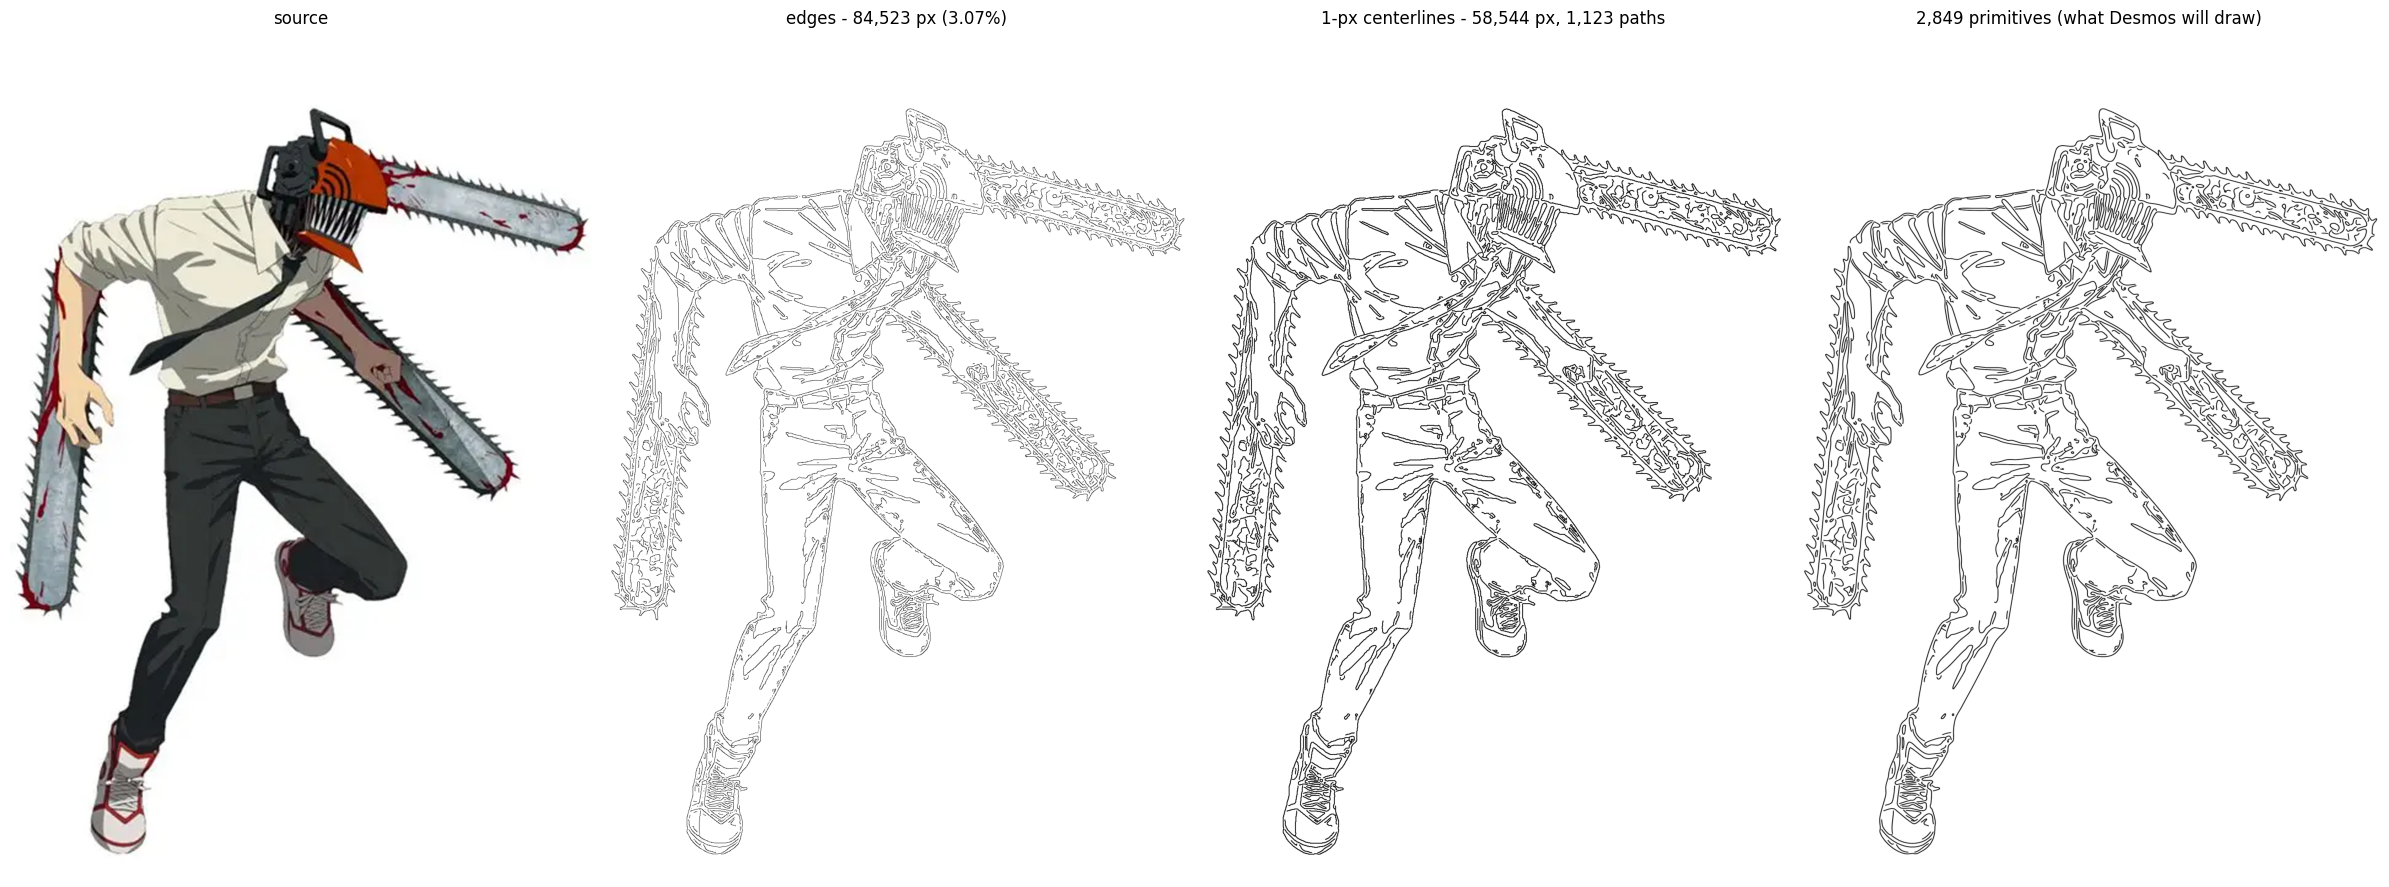

{
  "size": [
    1376,
    2000
  ],
  "edge_px": 84523,
  "edge_density_%": 3.07,
  "skeleton_px": 58544,
  "paths_traced": 1123,
  "spurs_pruned": 187,
  "paths_kept": 991,
  "paths_dropped_short": 132,
  "fit_err_used_px": 1.2,
  "primitives": 2849,
  "primitive_kinds": {
    "bezier": 2727,
    "line": 101,
    "conic": 21
  },
  "path_length_px": {
    "median": 29.6,
    "p90": 139.1,
    "longest": 1891.0,
    "total": 65962.0
  },
  "fidelity": {
    "coverage_%_within_1.5px": 97.73,
    "mean_dev_px": 0.525,
    "p95_dev_px": 1.026,
    "max_dev_px": 1.732
  },
  "seconds": 13.3
}


In [ ]:
import json
import numpy as np, cv2
import matplotlib.pyplot as plt
from importlib import reload # Import reload
import desmos_mega # Import the module first
reload(desmos_mega) # Reload the module to pick up changes
from desmos_mega import load_image, run_pipeline, render_curves

MAX_SIZE = 2000                       # keep identical to the Generate cell
img = load_image(image_path, MAX_SIZE)
h, w = img.shape[:2]

# defaults = detailed AND clean.  Tuning knobs (also available as CLI flags):
#   more faint detail : sens=1.3, sigma=1.2, min_len=8
#   calmer / cleaner  : sens=1.2, sigma=1.5-2.0, min_len=14
curves, rep, inter = run_pipeline(img)
drawing = render_curves(curves, h, w, ss=2)

skel_vis = cv2.dilate(inter["skeleton"].astype(np.uint8), np.ones((2, 2), np.uint8)) > 0
fig, ax = plt.subplots(1, 4, figsize=(24, 10))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[0].set_title("source")
ax[1].imshow(~inter["edges"], cmap="gray")
ax[1].set_title(f"edges - {rep['edge_px']:,} px ({rep['edge_density_%']}%)")
ax[2].imshow(~skel_vis, cmap="gray")
ax[2].set_title(f"1-px centerlines - {rep['skeleton_px']:,} px, {rep['paths_traced']:,} paths")
ax[3].imshow(drawing, cmap="gray")
ax[3].set_title(f"{len(curves):,} primitives (what Desmos will draw)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

print(json.dumps(rep, indent=2))

## 5 · Generate

In [ ]:
!python desmos_mega.py "{image_path}" --max-size 2000 --output insane --max-segments 8000

[1/3] load
      -> 1376 x 2000
[2/3] detect + trace + fit
      edges      : 84,523 px (3.07% of image)
      centerline : 58,544 px 1-px skeleton (islands < 14px removed)
      trace      : 1,123 paths, 187 spurs pruned
      fit        : 2,849 primitives {'bezier': 2727, 'line': 101, 'conic': 21}
      fidelity   : {'coverage_%_within_1.5px': 97.73, 'mean_dev_px': 0.525, 'p95_dev_px': 1.026, 'max_dev_px': 1.732}
      -> 2,849 Desmos expressions (0 duplicates removed)
[3/3] save
      -> insane.txt (0.34 MB)
      -> insane.json (0.66 MB)
      -> insane_report.json


## 6 · Download

In [ ]:
from google.colab import files
files.download('insane.txt')
files.download('insane.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>